# Data loading & cleaning (EDA part)

In [52]:
import pandas as pd
import numpy as np

# Load JHU Global Time-Series Data (Confirmed + Deaths)

url_confirmed = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/" \
                "csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"

url_deaths = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/" \
             "csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_global.csv"

df_conf = pd.read_csv(url_confirmed)
df_deaths = pd.read_csv(url_deaths)


# Aggregate to COUNTRY LEVEL (sum across provinces)

conf_country = df_conf.groupby("Country/Region").sum(numeric_only=True).reset_index()
deaths_country = df_deaths.groupby("Country/Region").sum(numeric_only=True).reset_index()

# Drop Lat and Long columns
conf_country = conf_country.drop(columns=["Lat", "Long"], errors="ignore")
deaths_country = deaths_country.drop(columns=["Lat", "Long"], errors="ignore")


# Convert from wide → long format

conf_long = conf_country.melt(
    id_vars="Country/Region",
    var_name="date",
    value_name="confirmed"
)

deaths_long = deaths_country.melt(
    id_vars="Country/Region",
    var_name="date",
    value_name="deaths"
)

# Merge confirmed + deaths into ONE dataset

df = pd.merge(
    conf_long,
    deaths_long,
    on=["Country/Region", "date"],
    how="left"
)
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], format='%m/%d/%y')
# Sort
df = df.sort_values(["Country/Region", "date"])
# Calculate NEW DAILY CASES & DEATHS
df["new_confirmed"] = df.groupby("Country/Region")["confirmed"].diff().fillna(0)
df["new_deaths"] = df.groupby("Country/Region")["deaths"].diff().fillna(0)
# Replace negative values (data corrections) with 0
df["new_confirmed"] = df["new_confirmed"].clip(lower=0)
df["new_deaths"] = df["new_deaths"].clip(lower=0)
# Display the cleaned dataset
print("\nFinal cleaned dataset (head):")
print(df.head())
print("\nINFO of final long-format dataset:")
print(df.info())



Final cleaned dataset (head):
    Country/Region       date  confirmed  deaths  new_confirmed  new_deaths
0      Afghanistan 2020-01-22          0       0            0.0         0.0
201    Afghanistan 2020-01-23          0       0            0.0         0.0
402    Afghanistan 2020-01-24          0       0            0.0         0.0
603    Afghanistan 2020-01-25          0       0            0.0         0.0
804    Afghanistan 2020-01-26          0       0            0.0         0.0

INFO of final long-format dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 229743 entries, 0 to 229742
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Country/Region  229743 non-null  object        
 1   date            229743 non-null  datetime64[ns]
 2   confirmed       229743 non-null  int64         
 3   deaths          229743 non-null  int64         
 4   new_confirmed   229743 non-null  float64       
 

# Map visualizations (2 different designs)

# Map Design 1 – Choropleth map (cumulative confirmed cases)

In [53]:
import plotly.express as px
latest_date = df["date"].max()
df_latest = df[df["date"] == latest_date]
fig_choro = px.choropleth(
    df_latest,
    locations="Country/Region",
    locationmode="country names",
    color="confirmed",
    hover_name="Country/Region",
    hover_data={"confirmed": ":,"},
    color_continuous_scale="Viridis",
    title=f"<b>Global Cumulative Confirmed COVID-19 Cases</b><br><sup>As of {latest_date.date()}</sup>"
)
fig_choro.update_layout(
    margin=dict(l=0, r=0, t=80, b=0),
    coloraxis_colorbar=dict(
        title="Confirmed Cases",
        tickformat=":,",
        thickness=15,
        len=0.60
    ),
    font=dict(size=14)
)
fig_choro.show()


# Map Design 2 – Bubble map (cumulative deaths)

In [54]:
fig_bubble = px.scatter_geo(
    df_latest,
    locations="Country/Region",
    locationmode="country names",
    size="deaths",
    color="deaths",
    hover_name="Country/Region",
    hover_data={
        "deaths": ":,",
        "confirmed": ":,",
    },
    projection="natural earth",
    size_max=50,
    color_continuous_scale="Reds",
    title=f"<b>Global Cumulative COVID-19 Deaths</b><br><sup>Bubble Map as of {latest_date.date()}</sup>"
)

fig_bubble.update_traces(
    marker=dict(
        line=dict(width=0.5, color="black"),
        opacity=0.75
    )
)

fig_bubble.update_layout(
    margin=dict(l=0, r=0, t=70, b=0),
    coloraxis_colorbar=dict(
        title="Deaths",
        tickformat=":,",
        len=0.6
    ),
    font=dict(size=14)
)

fig_bubble.show()


# Aggregation visualizations (2 different designs)

# Aggregation Design 1 – Histogram + KDE of log cases

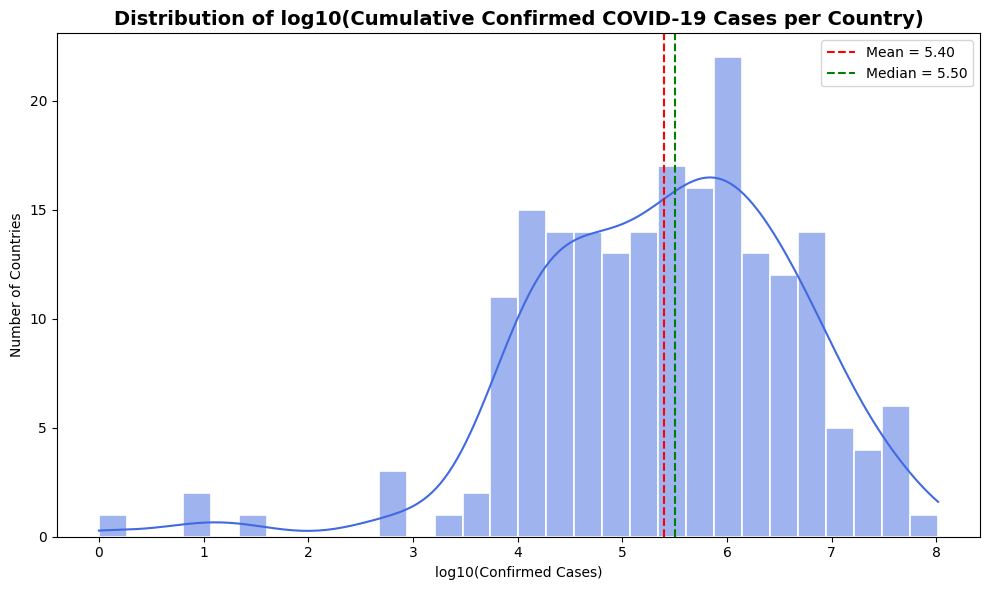

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data (log transform)
log_confirmed = np.log10(df_latest["confirmed"].replace(0, np.nan).dropna())

plt.figure(figsize=(10, 6))

sns.histplot(
    log_confirmed,
    bins=30,
    kde=True,
    color="royalblue",         # CUSTOM COLOR
    edgecolor="white",
    linewidth=1.2
)

# Add median + mean markers
plt.axvline(log_confirmed.mean(), color='red', linestyle='--', label=f"Mean = {log_confirmed.mean():.2f}")
plt.axvline(log_confirmed.median(), color='green', linestyle='--', label=f"Median = {log_confirmed.median():.2f}")

plt.title("Distribution of log10(Cumulative Confirmed COVID-19 Cases per Country)", fontsize=14, weight='bold')
plt.xlabel("log10(Confirmed Cases)")
plt.ylabel("Number of Countries")
plt.legend()
plt.tight_layout()
plt.show()


# Aggregation Design 2 – Boxplot

/tmp/ipython-input-1135989068.py:63: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




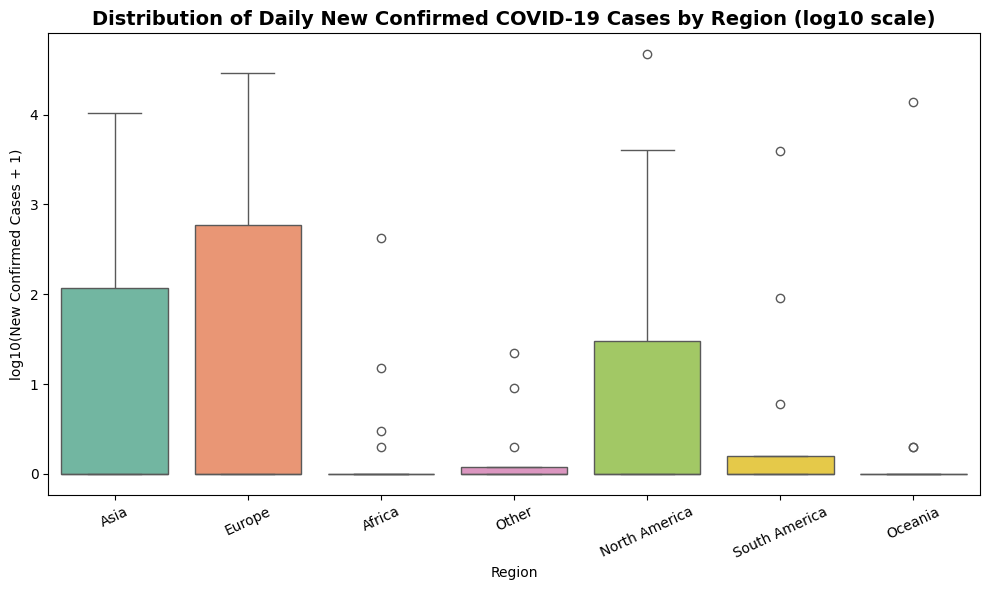

In [56]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

!pip install pycountry_convert
import pycountry_convert as pc


# Convert country → continent

def country_to_continent(country):
    try:

        mapping_fixes = {
            "US": "United States",
            "Russia": "Russian Federation",
            "Iran": "Iran, Islamic Republic of",
            "Venezuela": "Venezuela, Bolivarian Republic of",
            "Tanzania": "Tanzania, United Republic of",
            "Bolivia": "Bolivia, Plurinational State of",
            "Brunei": "Brunei Darussalam",
            "Congo (Brazzaville)": "Congo",
            "Congo (Kinshasa)": "Congo, The Democratic Republic of the",
            "Korea, South": "Korea, Republic of",
            "Korea, North": "Korea, Democratic People's Republic of",
            "Syria": "Syrian Arab Republic",
            "Laos": "Lao People's Democratic Republic"
        }

        if country in mapping_fixes:
            country = mapping_fixes[country]

        country_code = pc.country_name_to_country_alpha2(country)
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        return pc.convert_continent_code_to_continent_name(continent_code)

    except:
        return "Other"

# GET LATEST DATA

latest_date = df["date"].max()
df_latest = df[df["date"] == latest_date].copy()


# ADD REGION COLUMN

df_latest["Region"] = df_latest["Country/Region"].apply(country_to_continent)


# COMPUTE LOG-TRANSFORM OF NEW CASES

df_latest["log_new_confirmed"] = np.log10(df_latest["new_confirmed"] + 1)


# FINAL BOX PLOT

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_latest,
    x="Region",
    y="log_new_confirmed",
    palette="Set2"
)

plt.title("Distribution of Daily New Confirmed COVID-19 Cases by Region (log10 scale)",
          fontsize=14, weight="bold")
plt.xlabel("Region")
plt.ylabel("log10(New Confirmed Cases + 1)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


# Interactive visualizations (2 designs)

Design 1: Interactive Visualization (Animated Choropleth Map)

In [57]:
import pandas as pd
import plotly.express as px

# Load data
url_confirmed = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/" \
                "csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"

df_conf = pd.read_csv(url_confirmed)

# Aggregate by country
df_country = df_conf.groupby("Country/Region").sum(numeric_only=True).reset_index()
df_country = df_country.drop(columns=["Lat", "Long"])

# Melt to long format
df_long = df_country.melt(
    id_vars="Country/Region",
    var_name="date",
    value_name="confirmed"
)

# Convert dates
df_long["date"] = pd.to_datetime(df_long["date"], format="%m/%d/%y")

# Clean: keep monthly data only
df_long["year_month"] = df_long["date"].dt.to_period("M").astype(str)

df_monthly = df_long.groupby(["Country/Region", "year_month"]).max().reset_index()

# Animated Choropleth
fig = px.choropleth(
    df_monthly,
    locations="Country/Region",
    locationmode="country names",
    color="confirmed",
    hover_name="Country/Region",
    animation_frame="year_month",
    color_continuous_scale="Plasma",
    title="Animated Global Spread of COVID-19 (Monthly Confirmed Cases)"
)

fig.update_layout(
    margin=dict(l=0, r=0, t=50, b=0),
    coloraxis_colorbar=dict(title="Confirmed Cases"),
)

fig.show()



# Design 2: Interactive time series line chart

In [58]:
import plotly.express as px

# Select top 10 countries
top_countries = df_latest.nlargest(10, "confirmed")["Country/Region"].tolist()
df_top = df[df["Country/Region"].isin(top_countries)]


fig_ts = px.line(
    df_top,
    x="date",
    y="new_confirmed",
    color="Country/Region",
    markers=True,
    hover_data={"new_confirmed": ":,"},
    color_discrete_sequence=px.colors.qualitative.Set2,
    title=f"<b>Daily New COVID-19 Cases Over Time</b><br><sup>Top {len(top_countries)} Countries</sup>"
)

fig_ts.update_layout(
    xaxis_title="Date",
    yaxis_title="New Daily Confirmed Cases",
    hovermode="x unified",
    margin=dict(l=40, r=40, t=80, b=40)
)

fig_ts.show()


#Dropdown to select one country at a time

In [59]:
import plotly.express as px

# Create sorted list of top countries
country_list = sorted(top_countries)

# Prepare initial figure (first country)
initial_country = country_list[0]
df_initial = df[df["Country/Region"] == initial_country]

fig_ts_single = px.line(
    df_initial,
    x="date",
    y="confirmed",
    markers=True,
    hover_data={"confirmed": ":,"},
    title=f"Time Series of Cumulative Cases – {initial_country}",
    color_discrete_sequence=["#1f77b4"]
)

# Build dropdown menu
dropdown_buttons = []

for c in country_list:
    df_c = df[df["Country/Region"] == c]

    dropdown_buttons.append(
        dict(
            label=c,
            method="update",
            args=[
                {"x": [df_c["date"]],
                 "y": [df_c["confirmed"]]},
                {"title": f"Time Series of Cumulative COVID-19 Cases – {c}"}
            ]
        )
    )

fig_ts_single.update_layout(
    updatemenus=[
        dict(
            buttons=dropdown_buttons,
            direction="down",
            x=0.85,
            y=1.15,
            showactive=True
        )
    ],
    xaxis_title="Date",
    yaxis_title="Cumulative Confirmed Cases",
    hovermode="x unified",
    margin=dict(l=50, r=50, t=90, b=40)
)

fig_ts_single.show()

